# Object Detection Using YOLO Demonstration In Python

## Background

Rapid urbanization has increased parking challenges, leading to congestion and inefficient space utilization. Traditional monitoring methods are costly and not scalable. With advances in computer vision, models like YOLO (You Only Look Once) enable fast and accurate real-time detection of vehicles from images, making automated parking analysis feasible.

## Objective

The objective is to detect parked vehicles using YOLO (You Only Look Once) to estimate parking occupancy in real time. This helps improve space utilization, reduce congestion, and support smarter traffic and urban planning decisions.

### Import Libraries

In [4]:
#pip install ultralytics
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from IPython.display import display
from PIL import Image, ImageOps


### Load Image

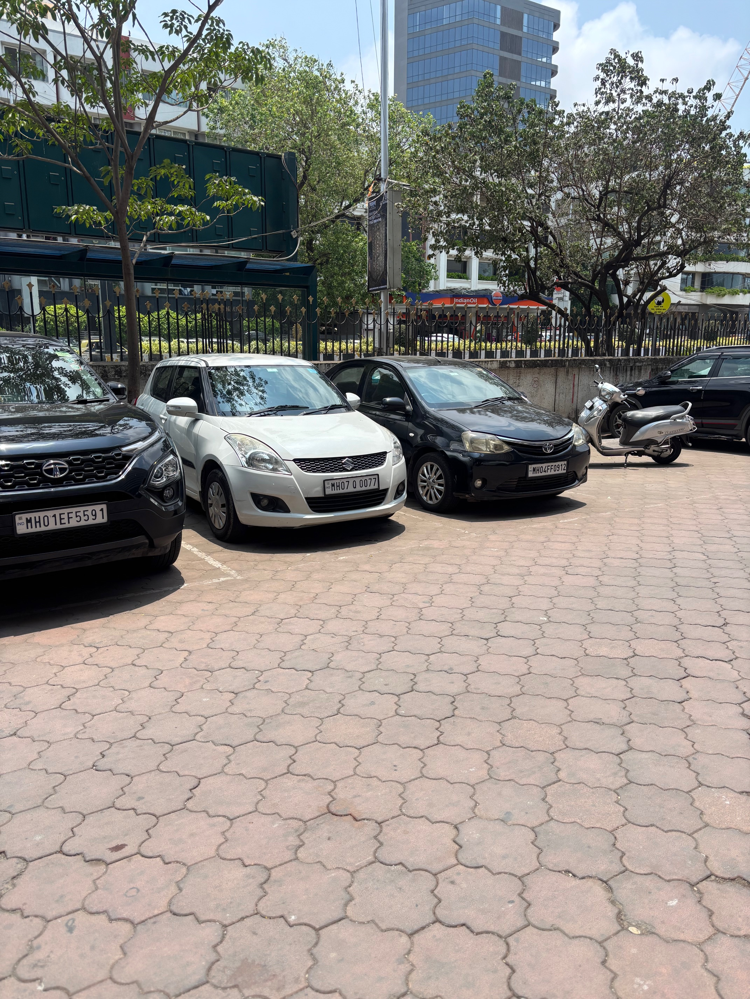

In [5]:
def load_image(path):
    image = Image.open(path).convert("RGB")
    image = ImageOps.exif_transpose(image)
    return image

image_path = "Vehicle Image.jpg"
image = load_image(image_path)
display(image)

### Load the model


In [6]:
model = YOLO('yolov8n.pt')

### Run detection


In [7]:
results = model(image)


0: 640x480 1 person, 4 cars, 1 motorcycle, 140.6ms
Speed: 15.0ms preprocess, 140.6ms inference, 8.7ms postprocess per image at shape (1, 3, 640, 480)


### Filter
We only want to count 'car', 'truck', 'bus', and 'motorcycle'

In [8]:
# Define the class IDs corresponding to vehicles (based on COCO dataset)
# 2 = car, 3 = motorcycle, 5 = bus, 7 = truck
target_classes = [2, 3, 5, 7]

# Extract detected bounding boxes from YOLO results (first image/frame)
detections = results[0].boxes

# Initialize counter for detected vehicles
vehicle_count = 0

# Loop through each detected object (bounding box)
for box in detections:

    # Check if the detected object's class belongs to vehicle categories
    if int(box.cls) in target_classes:

        # If yes, increment vehicle count
        vehicle_count += 1

### Visualize

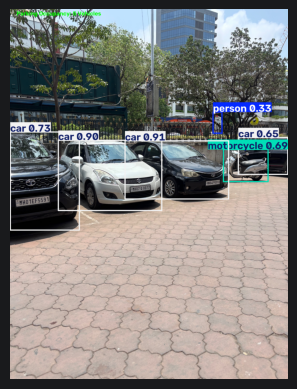

In [9]:
# Generate an image with detected bounding boxes drawn by YOLO
result_img = results[0].plot()  # YOLO overlays boxes, labels, and confidence scores


# Prepare the text to display vehicle count (parking occupancy)
text = f"Parking Occupancy: {vehicle_count} Vehicles"


# Add the text onto the image using OpenCV
cv2.putText(
    result_img,                 # Image on which text is drawn
    text,                       # Text to display
    (50, 50),                   # Position (x, y) ﷿﷿﷿ top-left corner of text
    cv2.FONT_HERSHEY_SIMPLEX,   # Font style
    1.5,                        # Font scale (size of text)
    (0, 255, 0),                # Text color in BGR (green)
    3,                          # Thickness of text
    cv2.LINE_AA                 # Anti-aliased line for smoother text
)

#Convert BGR ﷿﷿﷿ RGB (important for correct colors)
img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

#  Display image instead of printing array
plt.imshow(img_rgb)
plt.axis('off')  # Hide axes
plt.show()

### Display Total Objects Detected

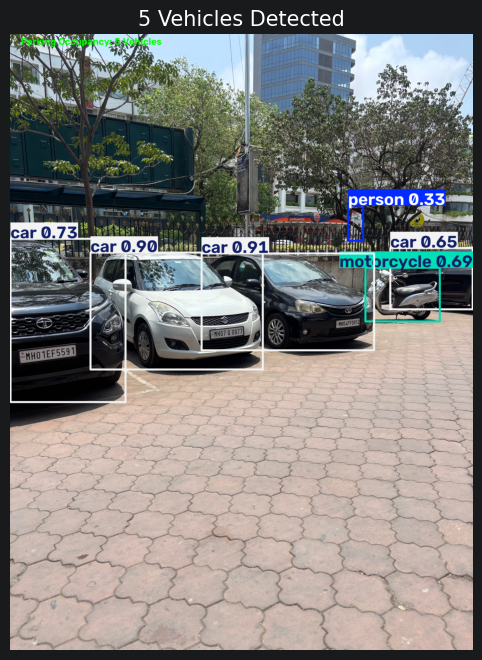

In [10]:
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title(f"{vehicle_count} Vehicles Detected", fontsize=15)
plt.axis('off')
plt.show()